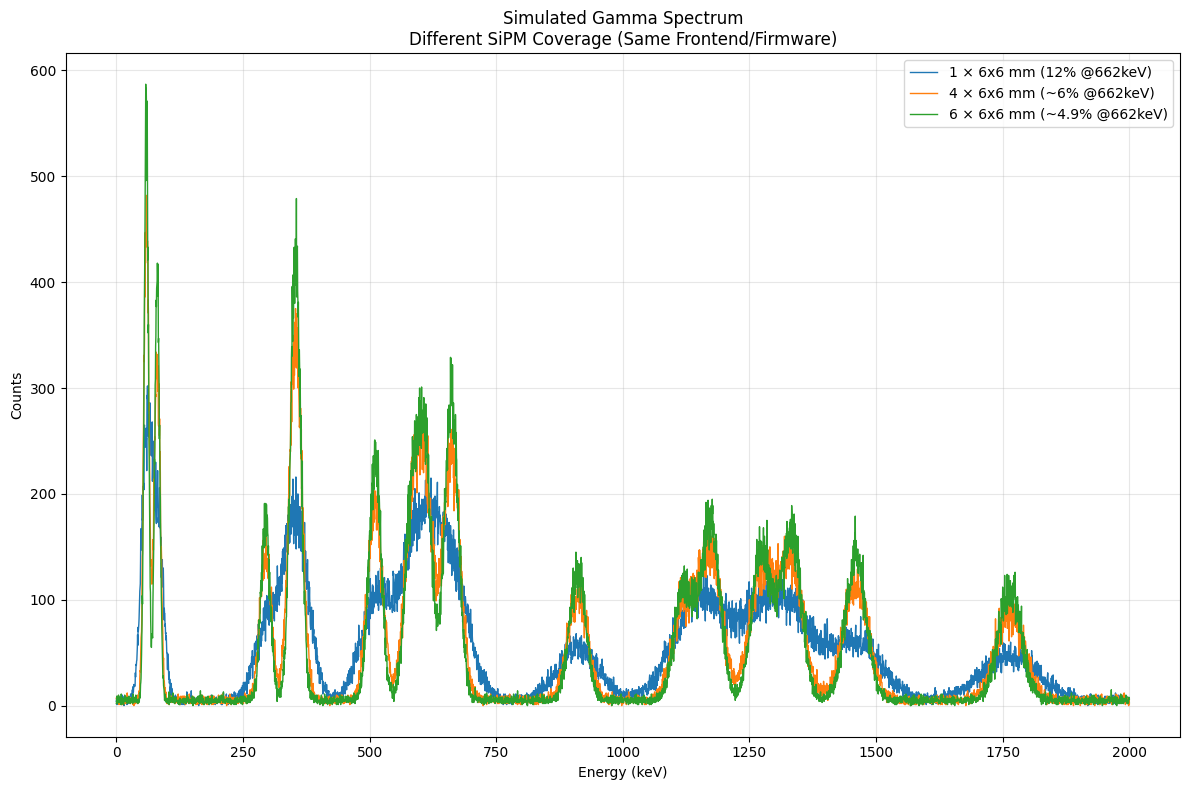

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Simulation Parameters
# ----------------------------

Emax = 2000  # keV
bins = 4096
energy_axis = np.linspace(0, Emax, bins)

# Isotopes (energy in keV, relative intensity)
isotopes = [
    (59.5, 0.6),
    (81, 0.5),
    (295, 0.4),
    (352, 0.5),
    (356, 0.6),
    (511, 0.7),
    (583, 0.6),
    (609, 0.8),
    (662, 1.0),
    (911, 0.5),
    (1120, 0.5),
    (1173, 0.8),
    (1274, 0.7),
    (1332, 0.8),
    (1460, 0.7),
    (1764, 0.6),
]

events_per_peak = 20000

# ----------------------------
# Detector Physics
# ----------------------------

# 1 SiPM baseline resolution (from earlier)
FWHM_1sipm_662 = 0.12  # 12% at 662 keV

def fwhm_at_energy(E, FWHM_662):
    # NaI resolution ~ 1/sqrt(E)
    return FWHM_662 * np.sqrt(662 / E)

def simulate_spectrum(FWHM_662):
    spectrum = np.zeros(bins)
    
    for energy, intensity in isotopes:
        fwhm = fwhm_at_energy(energy, FWHM_662)
        sigma = (fwhm * energy) / 2.35
        
        samples = np.random.normal(
            loc=energy,
            scale=sigma,
            size=int(events_per_peak * intensity)
        )
        
        hist, _ = np.histogram(samples, bins=bins, range=(0, Emax))
        spectrum += hist
        
    # Add background
    background = np.random.poisson(5, size=bins)
    spectrum += background
    
    return spectrum

# ----------------------------
# SiPM Configurations
# ----------------------------

# Resolution scales as 1/sqrt(N_sipm)

configs = {
    "1 × 6x6 mm (12% @662keV)": 0.12,
    "4 × 6x6 mm (~6% @662keV)": 0.12 / np.sqrt(4),
    "6 × 6x6 mm (~4.9% @662keV)": 0.12 / np.sqrt(6),
}

# ----------------------------
# Plot
# ----------------------------

plt.figure(figsize=(12, 8))

for label, fwhm in configs.items():
    spectrum = simulate_spectrum(fwhm)
    plt.plot(energy_axis, spectrum, label=label, linewidth=1)

plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.title("Simulated Gamma Spectrum\nDifferent SiPM Coverage (Same Frontend/Firmware)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()